In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('All imports successful.')

All imports successful.


In [3]:
df = pd.read_csv('/mnt/software_requirements_cleaned.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nType value counts:')
print(df['Type'].value_counts())
print('\nNull values:')
print(df.isnull().sum())

Shape: (527, 5)
Columns: ['Type', 'Description', 'Type_encoded', 'requirement_length', 'requirement_length_scaled']

Type value counts:
Type
F     198
US     61
O      55
SE     54
PE     52
LF     32
A      20
SC     20
MN     14
L      10
FT      9
PO      2
Name: count, dtype: int64

Null values:
Type                         0
Description                  0
Type_encoded                 0
requirement_length           0
requirement_length_scaled    0
dtype: int64


In [4]:
# Binary target: 1 = Functional, 0 = Non-Functional
df['is_functional'] = (df['Type'] == 'F').astype(int)
print('Class distribution:')
print(df['is_functional'].value_counts())
print(f'\nFunctional: {df["is_functional"].sum()} | Non-Functional: {(df["is_functional"]==0).sum()}')

# Features and target
X = df[['requirement_length', 'requirement_length_scaled']].values
y = df['is_functional'].values

# Normalize — critical for KNN since it's distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features shape:', X_scaled.shape)
print('Mean after scaling:', X_scaled.mean(axis=0).round(4))
print('Std after scaling: ', X_scaled.std(axis=0).round(4))

Class distribution:
is_functional
0    329
1    198
Name: count, dtype: int64

Functional: 198 | Non-Functional: 329
Features shape: (527, 2)
Mean after scaling: [-0.  0.]
Std after scaling:  [1. 1.]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 421 | Test size: 106


Best K: 15 → Test Accuracy: 0.6981


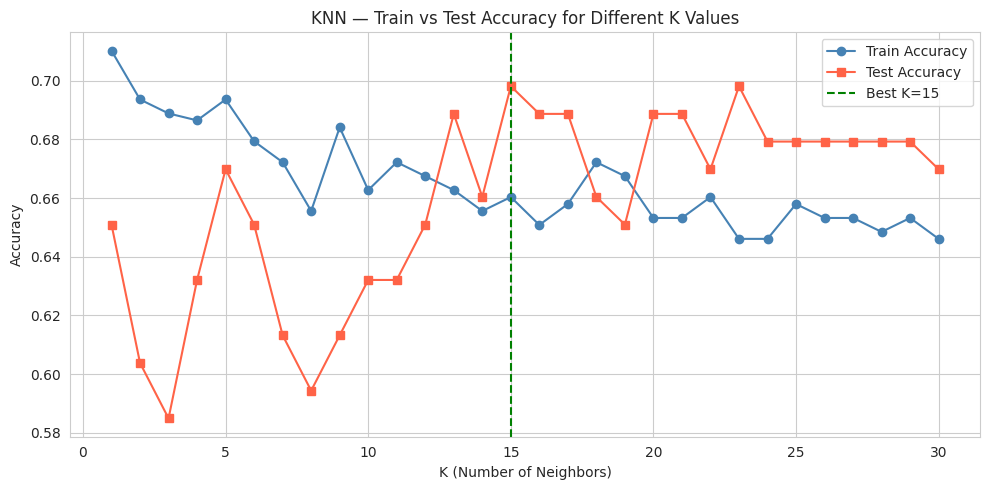

In [8]:
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = k_range.start + np.argmax(test_accuracies)
best_acc = max(test_accuracies)
print(f'Best K: {best_k} → Test Accuracy: {best_acc:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_accuracies, marker='o', label='Train Accuracy', color='steelblue')
ax.plot(k_range, test_accuracies, marker='s', label='Test Accuracy', color='tomato')
ax.axvline(best_k, linestyle='--', color='green', label=f'Best K={best_k}')
ax.set_xlabel('K (Number of Neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN — Train vs Test Accuracy for Different K Values')
ax.legend()
plt.tight_layout()
plt.savefig('../k_vs_accuracy.png', dpi=150)
plt.show()

In [9]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

print(f'Best K: {best_k}')
print(f'Train Accuracy: {accuracy_score(y_train, knn_best.predict(X_train)):.4f}')
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Functional', 'Functional']))

Best K: 15
Train Accuracy: 0.6603
Test Accuracy:  0.6981

Classification Report:
                precision    recall  f1-score   support

Non-Functional       0.71      0.88      0.78        66
    Functional       0.67      0.40      0.50        40

      accuracy                           0.70       106
     macro avg       0.69      0.64      0.64       106
  weighted avg       0.69      0.70      0.68       106



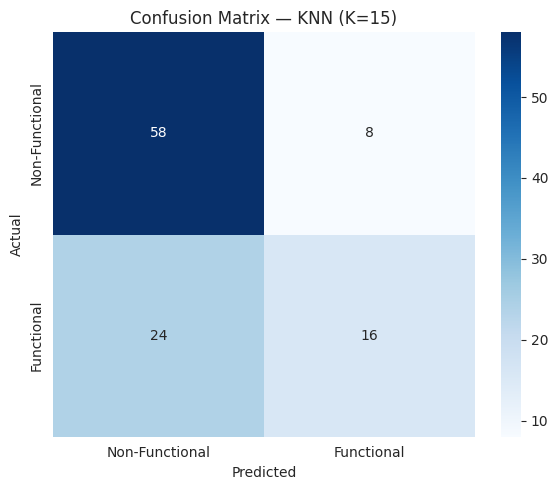

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Functional', 'Functional'],
            yticklabels=['Non-Functional', 'Functional'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — KNN (K={best_k})')
plt.tight_layout()
plt.savefig('../confusion_matrix.png', dpi=150)
plt.show()

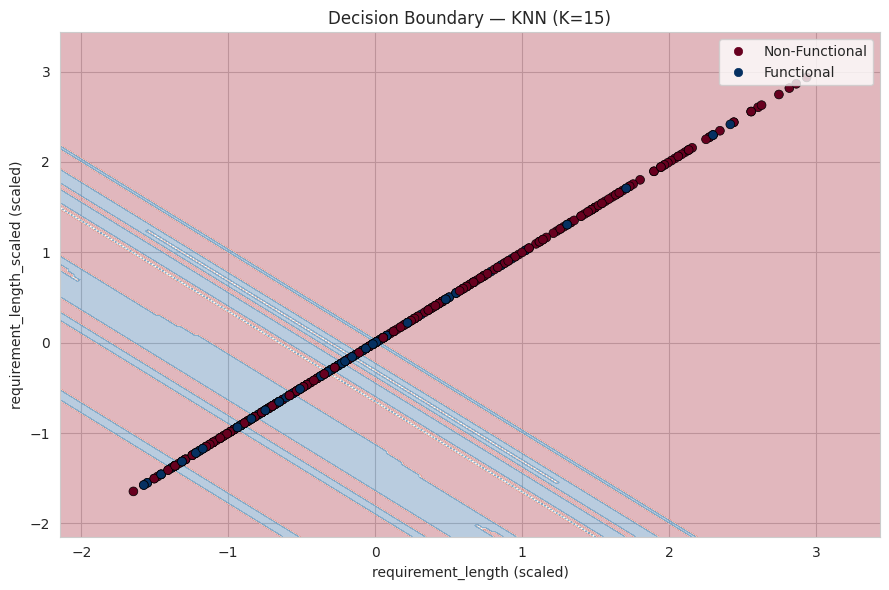

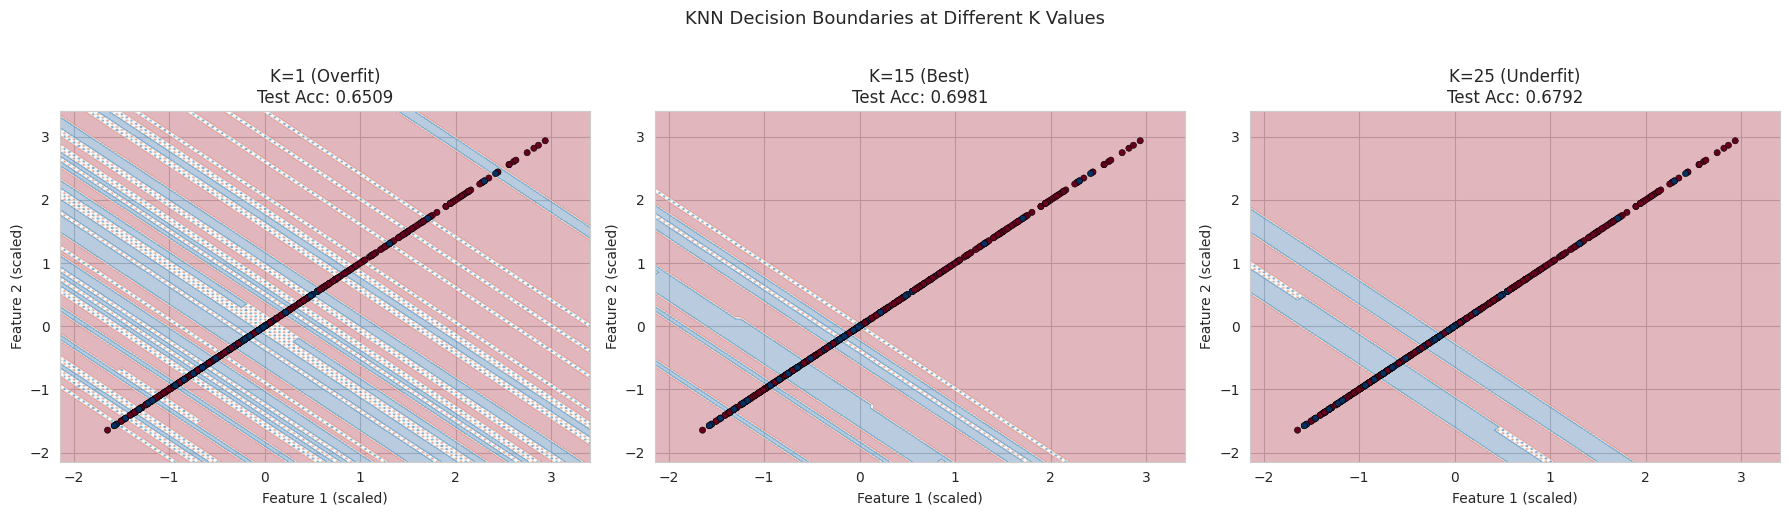

In [14]:
def plot_decision_boundary(model, X, y, title, filename):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu,
                         edgecolors='k', s=40, linewidths=0.5)
    handles, _ = scatter.legend_elements()
    ax.legend(handles, ['Non-Functional', 'Functional'], loc='upper right')
    ax.set_xlabel('requirement_length (scaled)')
    ax.set_ylabel('requirement_length_scaled (scaled)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'../{filename}', dpi=150)
    plt.show()

plot_decision_boundary(knn_best, X_scaled, y,
    f'Decision Boundary — KNN (K={best_k})', 'decision_boundary_best_k.png')

# Compare K=1 vs Best K vs K=25
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
h = 0.05
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for ax, k, label in zip(axes, [1, best_k, 25], ['K=1 (Overfit)', f'K={best_k} (Best)', 'K=25 (Underfit)']):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    Z = knn_tmp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = accuracy_score(y_test, knn_tmp.predict(X_test))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.RdBu,
               edgecolors='k', s=20, linewidths=0.4)
    ax.set_title(f'{label}\nTest Acc: {acc:.4f}')
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')

plt.suptitle('KNN Decision Boundaries at Different K Values', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../decision_boundary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

5-Fold CV Scores: [0.5755 0.5943 0.4857 0.6667 0.4952]
CV Mean: 0.5635 ± 0.0670


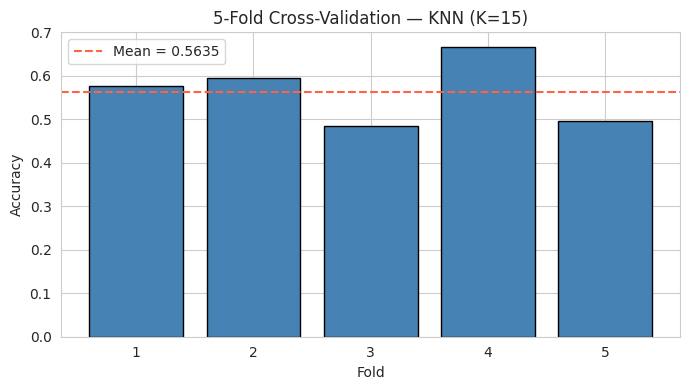

In [16]:
cv_scores = cross_val_score(knn_best, X_scaled, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Scores: {cv_scores.round(4)}')
print(f'CV Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='k')
ax.axhline(cv_scores.mean(), linestyle='--', color='tomato', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title(f'5-Fold Cross-Validation — KNN (K={best_k})')
ax.legend()
plt.tight_layout()
plt.savefig('../cross_validation.png', dpi=150)
plt.show()

euclidean    → Test Accuracy: 0.6981
manhattan    → Test Accuracy: 0.6981
chebyshev    → Test Accuracy: 0.6887


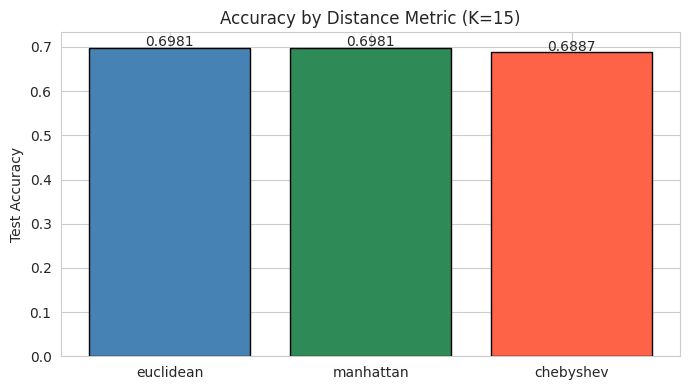

In [18]:
metrics = ['euclidean', 'manhattan', 'chebyshev']
metric_results = {}

for metric in metrics:
    knn_m = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn_m.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_m.predict(X_test))
    metric_results[metric] = acc
    print(f'{metric:12s} → Test Accuracy: {acc:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metric_results.keys(), metric_results.values(),
       color=['steelblue', 'seagreen', 'tomato'], edgecolor='k')
ax.set_ylabel('Test Accuracy')
ax.set_title(f'Accuracy by Distance Metric (K={best_k})')
for i, (k, v) in enumerate(metric_results.items()):
    ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../distance_metrics.png', dpi=150)
plt.show()

In [19]:
print('='*50)
print('TASK 6 — KNN CLASSIFICATION SUMMARY')
print('='*50)
print(f'Dataset         : software_requirements_cleaned.csv')
print(f'Samples         : {len(df)}')
print(f'Features        : requirement_length, requirement_length_scaled')
print(f'Target          : is_functional (binary)')
print(f'Best K          : {best_k}')
print(f'Test Accuracy   : {best_acc:.4f}')
print(f'CV Mean (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Best Metric     : {max(metric_results, key=metric_results.get)}')
print('='*50)

TASK 6 — KNN CLASSIFICATION SUMMARY
Dataset         : software_requirements_cleaned.csv
Samples         : 527
Features        : requirement_length, requirement_length_scaled
Target          : is_functional (binary)
Best K          : 15
Test Accuracy   : 0.6981
CV Mean (5-fold): 0.5635 ± 0.0670
Best Metric     : euclidean
